## Test metric DCE

In [2]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.colors import TwoSlopeNorm

current_directory = Path.cwd().resolve()

candidate_directories = (
    current_directory,
    *current_directory.parents,
)

project_root = next(
    (
        directory
        for directory in candidate_directories
        if (
            directory
            / "hj_reachability"
        ).is_dir()
        and (
            directory
            / "setup.py"
        ).is_file()
    ),
    None,
)

if project_root is None:
    raise FileNotFoundError(
               "Repository root not found."
    )

if str(project_root) not in sys.path:
    sys.path.insert(
        0,
        str(project_root),
    )

import hj_reachability as hj

from hj_reachability.systems.relative_vehicle_6d import (
    RelativeVehicle6D,
)
from hj_reachability.vehicle.geometry import (
    build_terminal_set_boundary,
)
from hj_reachability.vehicle.metrics import metricDCE

print("Project root:")
print(project_root)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Project root:
/home/alessio-grisorio/TESI/hj_reachability


## Configurazione test

In [3]:
STATE_NAMES = (
    "x_rel",
    "y_rel",
    "theta_rel",
    "v_H",
    "delta_E",
    "v_E",
)

GRID_LO = np.array(
    [
        -8.0,
        -6.0,
        -np.pi / 4,
        1.0,
        -np.pi / 12,
        1.0,
    ],
    dtype=np.float32,
)

GRID_HI = np.array(
    [
        17.0,
        6.0,
        np.pi / 4,
        11.0,
        np.pi / 12,
        11.0,
    ],
    dtype=np.float32,
)

# Griglia ridotta per il test.
GRID_SHAPE = (
    21,
    15,
    9,
    3,
    3,
    3,
)

PERIODIC_DIMS = ()

DCE_HORIZON = 3.0
DCE_DT = 0.01
DCE_BATCH_SIZE = 25_000

print(
    "Numero totale di punti:",
    int(np.prod(GRID_SHAPE)),
)

Numero totale di punti: 76545


In [4]:
grid = (
    hj.Grid
    .from_lattice_parameters_and_boundary_conditions(
        domain=hj.sets.Box(
            lo=jnp.asarray(GRID_LO),
            hi=jnp.asarray(GRID_HI),
        ),
        shape=GRID_SHAPE,
        periodic_dims=PERIODIC_DIMS,
    )
)

print("Ordine dello stato:")
print(STATE_NAMES)
print()

print("Forma della griglia:")
print(grid.shape)

print()

for dimension, name in enumerate(
    STATE_NAMES
):
    vector = np.asarray(
        grid.coordinate_vectors[dimension]
    )

    print(
        f"{dimension}: {name:10s} | "
        f"[{vector[0]: .4f}, "
        f"{vector[-1]: .4f}] | "
        f"N = {vector.size}"
    )

E0902 15:13:38.414276   26650 cuda_executor.cc:1348] [0] Failed to allocate device memory of 2.76GiB (2967470080 bytes): RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
=== Source Location Trace: === 
external/xla+/xla/stream_executor/cuda/cuda_status.cc:45
external/xla+/xla/stream_executor/cuda/cuda_device_allocator.cc:226
external/xla+/xla/stream_executor/cuda/cuda_device_allocator.cc:389

E0902 15:13:38.414306   26650 cuda_executor.cc:1348] [0] Failed to allocate device memory of 2.49GiB (2670723072 bytes): RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
=== Source Location Trace: === 
external/xla+/xla/stream_executor/cuda/cuda_status.cc:45
external/xla+/xla/stream_executor/cuda/cuda_device_allocator.cc:226
external/xla+/xla/stream_executor/cuda/cuda_device_allocator.cc:389

E0902 15:13:38.414322   26650 cuda_executor.cc:1348] [0] Failed to allocate device memory of 2.24GiB (2403650816 bytes): RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory

Ordine dello stato:
('x_rel', 'y_rel', 'theta_rel', 'v_H', 'delta_E', 'v_E')

Forma della griglia:
(21, 15, 9, 3, 3, 3)

0: x_rel      | [-8.0000,  17.0000] | N = 21
1: y_rel      | [-6.0000,  6.0000] | N = 15
2: theta_rel  | [-0.7854,  0.7854] | N = 9
3: v_H        | [ 1.0000,  11.0000] | N = 3
4: delta_E    | [-0.2618,  0.2618] | N = 3
5: v_E        | [ 1.0000,  11.0000] | N = 3


## Geometria e dinamica

In [5]:
boundary = build_terminal_set_boundary(
    n_theta=90,
    n_phi=180,
)

dynamics = RelativeVehicle6D(
    lf=1.2,
    lr=1.5,
    ego_min_acceleration=-7.0,
    ego_max_acceleration=2.5,
    ego_max_steering_rate=0.087,
    human_min_acceleration=-7.0,
    human_max_acceleration=2.5,
    human_max_yaw_rate=1.0,
    control_mode="max",
    disturbance_mode="min",
)

print("Terminal-set boundary shape:")
print(boundary.shape)

print()

print("Dynamics:")
print(type(dynamics).__name__)

Terminal-set boundary shape:
(90, 180, 2)

Dynamics:
RelativeVehicle6D


## Calcolo DCE (e TCE)

In [6]:
result = metricDCE(
    grid=grid,
    dynamics=dynamics,
    boundary=boundary,
    horizon=DCE_HORIZON,
    dt=DCE_DT,
    batch_size=DCE_BATCH_SIZE,
)

DCE = np.asarray(
    result.dce
)

TCE = np.asarray(
    result.tce
)

V0 = np.asarray(
    result.terminal_values
)

print("DCE shape:", DCE.shape)
print("TCE shape:", TCE.shape)
print("V0 shape: ", V0.shape)

print()

print(
    "DCE range: "
    f"[{DCE.min():.6f}, "
    f"{DCE.max():.6f}]"
)

print(
    "TCE range: "
    f"[{TCE.min():.6f}, "
    f"{TCE.max():.6f}] s"
)

print(
    "Angular scale: "
    f"{result.angular_scale:.6f} m/rad"
)

print(
    "All values valid:",
    bool(
        np.asarray(result.valid).all()
    ),
)

print(
    "V0 equals DCE:",
    bool(
        np.allclose(V0, DCE)
    ),
)

DCE shape: (21, 15, 9, 3, 3, 3)
TCE shape: (21, 15, 9, 3, 3, 3)
V0 shape:  (21, 15, 9, 3, 3, 3)

DCE range: [-3.408773, 13.482062]
TCE range: [0.000000, 3.000000] s
Angular scale: 5.738413 m/rad
All values valid: True
V0 equals DCE: True


## Visualizzazione

In [7]:
coordinate_vectors = [
    np.asarray(vector, dtype=float)
    for vector in grid.coordinate_vectors
]

x_axis = coordinate_vectors[0]
y_axis = coordinate_vectors[1]
theta_axis = coordinate_vectors[2]
v_H_axis = coordinate_vectors[3]
delta_E_axis = coordinate_vectors[4]
v_E_axis = coordinate_vectors[5]

THETA_TARGET_DEG = 0.0
V_H_TARGET = 6.0
DELTA_E_TARGET_DEG = 0.0
V_E_TARGET = 6.0


def nearest_index(
    vector: np.ndarray,
    value: float,
) -> int:
    return int(
        np.argmin(
            np.abs(vector - value)
        )
    )


i_theta = nearest_index(
    theta_axis,
    np.deg2rad(THETA_TARGET_DEG),
)

i_v_H = nearest_index(
    v_H_axis,
    V_H_TARGET,
)

i_delta_E = nearest_index(
    delta_E_axis,
    np.deg2rad(DELTA_E_TARGET_DEG),
)

i_v_E = nearest_index(
    v_E_axis,
    V_E_TARGET,
)

DCE_slice = DCE[
    :,
    :,
    i_theta,
    i_v_H,
    i_delta_E,
    i_v_E,
]

TCE_slice = TCE[
    :,
    :,
    i_theta,
    i_v_H,
    i_delta_E,
    i_v_E,
]

print(
    "theta_rel:",
    np.rad2deg(theta_axis[i_theta]),
    "deg",
)

print(
    "v_H:",
    v_H_axis[i_v_H],
    "m/s",
)

print(
    "delta_E:",
    np.rad2deg(delta_E_axis[i_delta_E]),
    "deg",
)

print(
    "v_E:",
    v_E_axis[i_v_E],
    "m/s",
)

theta_rel: 0.0 deg
v_H: 6.0 m/s
delta_E: 0.0 deg
v_E: 6.0 m/s


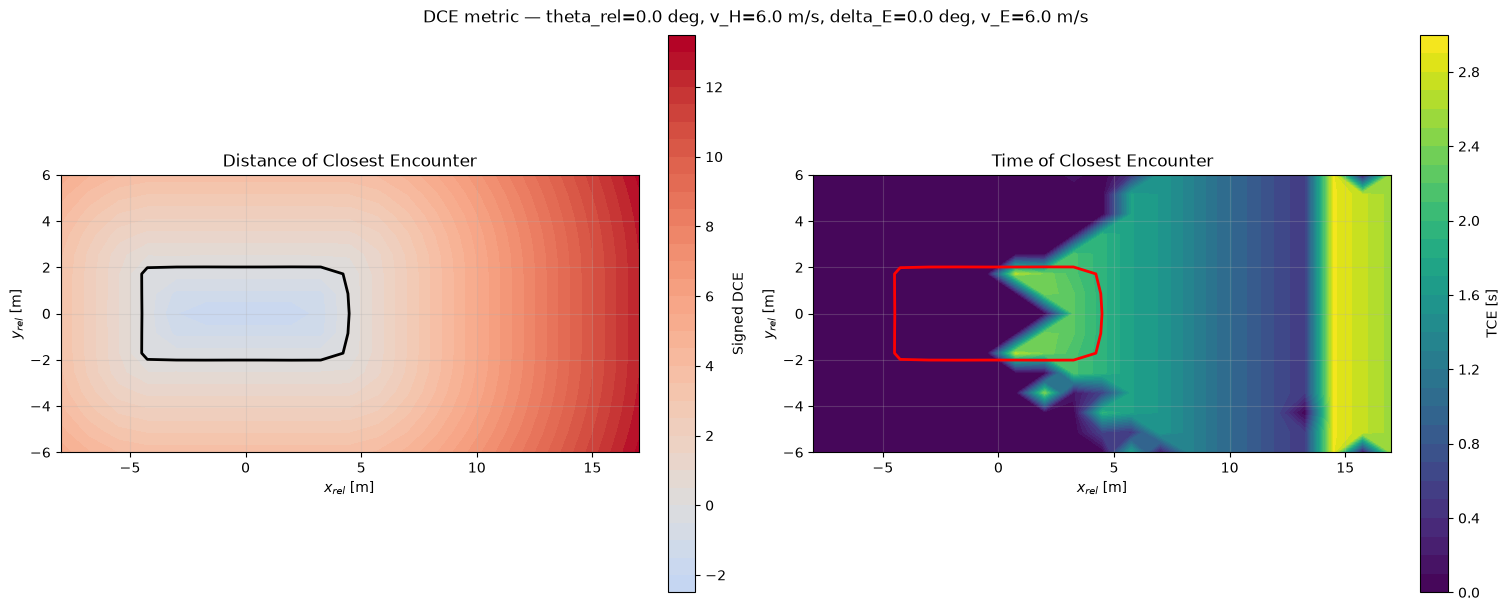

In [8]:
dce_limit = max(
    abs(float(np.nanmin(DCE_slice))),
    abs(float(np.nanmax(DCE_slice))),
    1e-12,
)

dce_norm = TwoSlopeNorm(
    vmin=-dce_limit,
    vcenter=0.0,
    vmax=dce_limit,
)

figure, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(15, 6),
    constrained_layout=True,
)

# ---------------------------------------------------------
# DCE
# ---------------------------------------------------------

dce_contour = axes[0].contourf(
    x_axis,
    y_axis,
    DCE_slice.T,
    levels=31,
    cmap="coolwarm",
    norm=dce_norm,
)

if (
    np.nanmin(DCE_slice) <= 0.0
    and np.nanmax(DCE_slice) >= 0.0
):
    axes[0].contour(
        x_axis,
        y_axis,
        DCE_slice.T,
        levels=[0.0],
        colors="black",
        linewidths=2.0,
    )

figure.colorbar(
    dce_contour,
    ax=axes[0],
    label="Signed DCE",
)

axes[0].set_title(
    "Distance of Closest Encounter"
)

axes[0].set_xlabel(
    r"$x_{rel}$ [m]"
)

axes[0].set_ylabel(
    r"$y_{rel}$ [m]"
)

axes[0].set_aspect(
    "equal",
    adjustable="box",
)

axes[0].grid(
    True,
    alpha=0.25,
)

# ---------------------------------------------------------
# TCE
# ---------------------------------------------------------

tce_contour = axes[1].contourf(
    x_axis,
    y_axis,
    TCE_slice.T,
    levels=np.linspace(
        0.0,
        DCE_HORIZON,
        31,
    ),
    cmap="viridis",
)

figure.colorbar(
    tce_contour,
    ax=axes[1],
    label="TCE [s]",
)

if (
    np.nanmin(DCE_slice) <= 0.0
    and np.nanmax(DCE_slice) >= 0.0
):
    axes[1].contour(
        x_axis,
        y_axis,
        DCE_slice.T,
        levels=[0.0],
        colors="red",
        linewidths=2.0,
    )

axes[1].set_title(
    "Time of Closest Encounter"
)

axes[1].set_xlabel(
    r"$x_{rel}$ [m]"
)

axes[1].set_ylabel(
    r"$y_{rel}$ [m]"
)

axes[1].set_aspect(
    "equal",
    adjustable="box",
)

axes[1].grid(
    True,
    alpha=0.25,
)

figure.suptitle(
    "DCE metric — "
    f"theta_rel="
    f"{np.rad2deg(theta_axis[i_theta]):.1f} deg, "
    f"v_H={v_H_axis[i_v_H]:.1f} m/s, "
    f"delta_E="
    f"{np.rad2deg(delta_E_axis[i_delta_E]):.1f} deg, "
    f"v_E={v_E_axis[i_v_E]:.1f} m/s"
)

plt.show()